* DSC630
* Week 3
* Dan Morrow

#### Week 3 assignment 

In this assignment, you will be using data on the Los Angeles Dodgers Major League Baseball (MLB) team located here: dodgers.csv. Use this data to make a recommendation to management on how to improve attendance. Tell a story with your analysis and clearly explain the steps you take to arrive at your conclusion. This is an open-ended question, and there is no one right answer. You are welcome to do additional research and/or use domain knowledge to assist your analysis, but clearly state any assumptions you make.


# Dodgers Attendance Recommendation

## Business Question

How can the Los Angeles Dodgers use attendance patterns and promotional scheduling to improve home game attendance?

The goal of this analysis is to look at which factors appear connected to higher or lower attendance and use those patterns to make a recommendation to management.

## Recommendation to Management

After conducting an analysis, my recommendation is that Dodgers management should use high-interest bobblehead promotions on games that are more likely to have lower attendance, especially weaker weekdays such as Monday and Wednesday games.

The goal is to improve attendance in a way that supports revenue, fan spending, and long-term fan interest. The data suggests that bobblehead games were connected with higher attendance, while opponent, weather, and game time did not show as strong of a pattern.

This does not mean the Dodgers should simply add more promotions. A better approach is to use the strongest promotions more intentionally and test whether they can help lift games that normally draw smaller crowds.

## Analysis Plan

To support the recommendation, I looked at the overall attendance baseline, attendance by day of week, attendance by opponent, promotion types, specific bobblehead giveaways, and weather/game time conditions. Since this is observational data, the analysis shows patterns and relationships, not guaranteed cause and effect. Let's walk through how I arrived at my recommendation. 



#### Important Assumption About the Dataset
The uploaded file is named `dodgers-2022.csv`, but the dates and day-of-week values appear to match the Dodgers 2012 season schedule. For example, April 10 is listed as a Tuesday, which matches 2012 rather than 2022. Because of this, I treated the dataset as a Dodgers home-season attendance dataset and used 2012 when creating the game date field.

This matters because the original dataset only shows whether a game had a bobblehead promotion. It does not say which bobblehead was given away. To add more detail, I used MLB’s 2012 Dodgers bobblehead schedule to match giveaway names to the correct game dates.


_______________________

## Overall Attendance Baseline

To begin, I looked at the overall attendance numbers to establish a baseline for the season. The Dodgers averaged about 41,040 fans per home game, but attendance varied quite a bit. The lowest-attended game had 24,312 fans, while the highest-attended games reached 56,000 fans.

Before looking at the lowest and highest games, I added a few supporting columns to make the results easier to read. The original dataset stores the month and day separately, so I created a `game_date` column. I also added a numeric month column to help create that date. Since the dates and weekdays in the file appear to match the 2012 Dodgers schedule, I used 2012 when creating the date field.

The new `game_date` column combines the separate month and day values into one date field. This makes the attendance results easier to sort, read, and eventually merge with supplemental bobblehead giveaway information.

In [16]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Load the Dodgers dataset
dodgers = pd.read_csv("dodgers-2022.csv")

#Output the dataset
dodgers.head()

,month,day,attend,day_of_week,opponent,temp,skies,day_night,cap,shirt,fireworks,bobblehead
0,APR,10,56000,Tuesday,Pirates,67,Clear,Day,NO,NO,NO,NO
1,APR,11,29729,Wednesday,Pirates,58,Cloudy,Night,NO,NO,NO,NO
2,APR,12,28328,Thursday,Pirates,57,Cloudy,Night,NO,NO,NO,NO
3,APR,13,31601,Friday,Padres,54,Cloudy,Night,NO,NO,YES,NO
4,APR,14,46549,Saturday,Padres,57,Cloudy,Night,NO,NO,NO,NO


In [17]:
#Create a map to convert month abbreviations into month numbers
month_map = {
    "APR": 4,
    "MAY": 5,
    "JUN": 6,
    "JUL": 7,
    "AUG": 8,
    "SEP": 9,
    "OCT": 10
}
#Create a numeric month column
dodgers["month_num"] = dodgers["month"].map(month_map)

#Create one date column using the 2012 season year
dodgers["game_date"] = pd.to_datetime({
    "year": 2012,
    "month": dodgers["month_num"],
    "day": dodgers["day"]
})

#Output new date column
dodgers[["month", "day", "day_of_week", "game_date"]].head()

,month,day,day_of_week,game_date
0,APR,10,Tuesday,2012-04-10
1,APR,11,Wednesday,2012-04-11
2,APR,12,Thursday,2012-04-12
3,APR,13,Friday,2012-04-13
4,APR,14,Saturday,2012-04-14


## Average Attendance
The Dodgers averaged just over 41,000 fans per home game. The lowest-attended game had a little over 24,000 fans, while the highest-attended games reached 56,000 fans. This shows that attendance varied quite a bit across the season, which gives management an opportunity to focus on games that are more likely to fall below average.

In [18]:
#Create a simple attendance summary table
attendance_summary = pd.DataFrame({
    "Metric": [
        "Number of home games",
        "Average attendance",
        "Middle attendance value",
        "Lowest attendance",
        "Highest attendance"
    ],
    "Attendance": [
        dodgers["attend"].count(),
        dodgers["attend"].mean(),
        dodgers["attend"].median(),
        dodgers["attend"].min(),
        dodgers["attend"].max()
    ]
})

#Round attendance values and convert them to whole numbers
attendance_summary["Attendance"] = attendance_summary["Attendance"].round(0).astype(int)

#Output summary table
attendance_summary

,Metric,Attendance
0,Number of home games,81
1,Average attendance,41040
2,Middle attendance value,40284
3,Lowest attendance,24312
4,Highest attendance,56000


___________

## Lowest Attended Games
The lowest-attended games were mostly weekday games, especially Monday, Wednesday, and Thursday games. These games also generally did not include bobblehead promotions. This starts to support the idea that weaker attendance games may be connected to both timing and promotion strategy.

In [19]:
#Sort games from lowest to highest attendance
lowest_attendance = dodgers.sort_values("attend").head(10)

#Output details for the 10 lowest-attended games
lowest_attendance[["game_date", "day_of_week", "opponent", "attend", "bobblehead", "fireworks"]]

,game_date,day_of_week,opponent,attend,bobblehead,fireworks
18,2012-05-14,Monday,Snakes,24312,NO,NO
28,2012-05-30,Wednesday,Brewers,25509,NO,NO
8,2012-04-25,Wednesday,Braves,26345,NO,NO
6,2012-04-23,Monday,Braves,26376,NO,NO
29,2012-05-31,Thursday,Brewers,26773,NO,NO
2,2012-04-12,Thursday,Pirates,28328,NO,NO
1,2012-04-11,Wednesday,Pirates,29729,NO,NO
3,2012-04-13,Friday,Padres,31601,NO,YES
67,2012-09-02,Sunday,Snakes,31607,NO,NO
46,2012-07-16,Monday,Phillies,32238,NO,NO


________________

### Highest Attended Games

The highest-attended games show a different pattern from the lowest-attended games. Several of the top games included bobblehead promotions, and the attendance numbers are much closer to the stadium’s upper range. This does not prove that bobbleheads caused the increase by themselves, but it does show that bobblehead games are repeatedly connected with stronger attendance.

This supports the business recommendation that bobbleheads may be useful as a targeted tool, especially if they are scheduled on games that need help instead of only on games that may already draw well.

In [20]:
#Sort games from highest to lowest attendance
highest_attendance = dodgers.sort_values("attend", ascending=False).head(10)

#Output details for the 10 highest-attended games
highest_attendance[["game_date", "day_of_week", "opponent", "attend", "bobblehead", "fireworks"]]

,game_date,day_of_week,opponent,attend,bobblehead,fireworks
0,2012-04-10,Tuesday,Pirates,56000,NO,NO
59,2012-08-21,Tuesday,Giants,56000,YES,NO
39,2012-07-01,Sunday,Mets,55359,YES,NO
31,2012-06-12,Tuesday,Angels,55279,YES,NO
56,2012-08-07,Tuesday,Rockies,55024,YES,NO
64,2012-08-30,Thursday,Snakes,54621,YES,NO
10,2012-04-28,Saturday,Nationals,54242,YES,NO
44,2012-07-14,Saturday,Padres,54014,YES,NO
42,2012-07-04,Wednesday,Reds,53570,NO,YES
35,2012-06-17,Sunday,White Sox,53504,NO,NO


_________

## Attendance by Day of Week

Attendance by day of week shows that Monday and Wednesday were the weakest attendance days. Monday averaged about 34,966 fans per game, while Wednesday averaged about 37,585. Tuesday had the highest average attendance at about 47,741 fans, but that result should be viewed carefully because several Tuesday games included bobblehead promotions.

This pattern supports the recommendation that the Dodgers should look first at weaker weekdays when deciding where to place high-interest promotions.

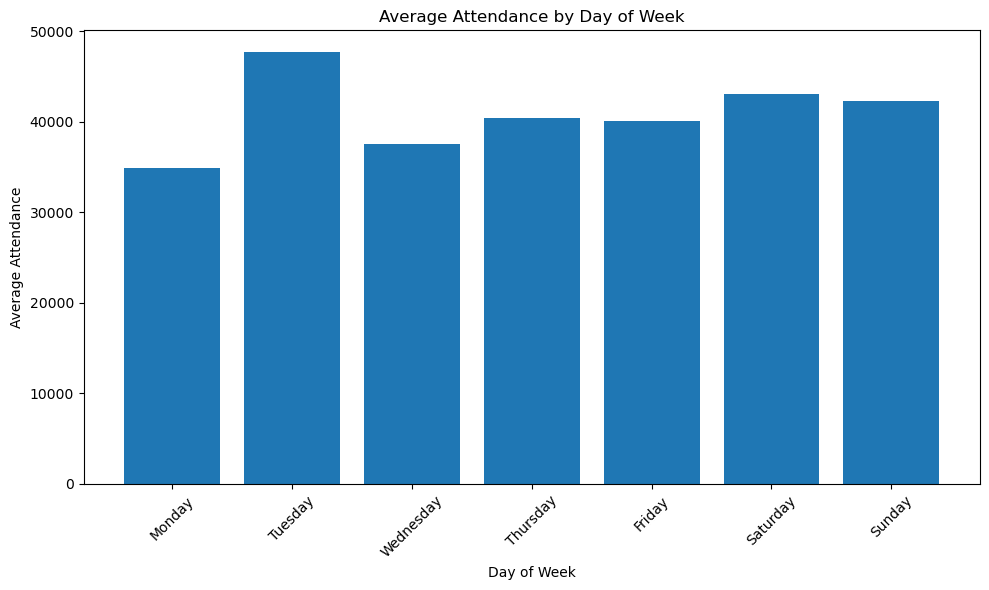

In [21]:
#Calculate average attendance by day of week
attendance_by_day = dodgers.groupby("day_of_week")["attend"].mean().reset_index()

#Put days in normal calendar order
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

attendance_by_day["day_of_week"] = pd.Categorical(
    attendance_by_day["day_of_week"],
    categories=day_order,
    ordered=True
)

attendance_by_day = attendance_by_day.sort_values("day_of_week")

#Create a bar chart for average attendance by day of week and output
plt.figure(figsize=(10, 6))

plt.bar(attendance_by_day["day_of_week"], attendance_by_day["attend"])

plt.title("Average Attendance by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Attendance")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

________________

## Attendance by Opponent

Next, I looked at average attendance by opponent. The graph shows some variation, but the pattern is not strong enough to say that opponent alone explains attendance. A few opponents, such as the Angels, Mets, and Nationals, had higher average attendance near 50,000 fans. The Braves were the lowest, averaging closer to the low 30,000s.

Most opponents, however, fall in a middle range between roughly 38,000 and 44,000 fans. Because the differences are not extreme for most teams, opponent does not appear to be the strongest factor in attendance. This suggests that other factors, such as promotions or day of week, may be more useful to focus on when building the recommendation.

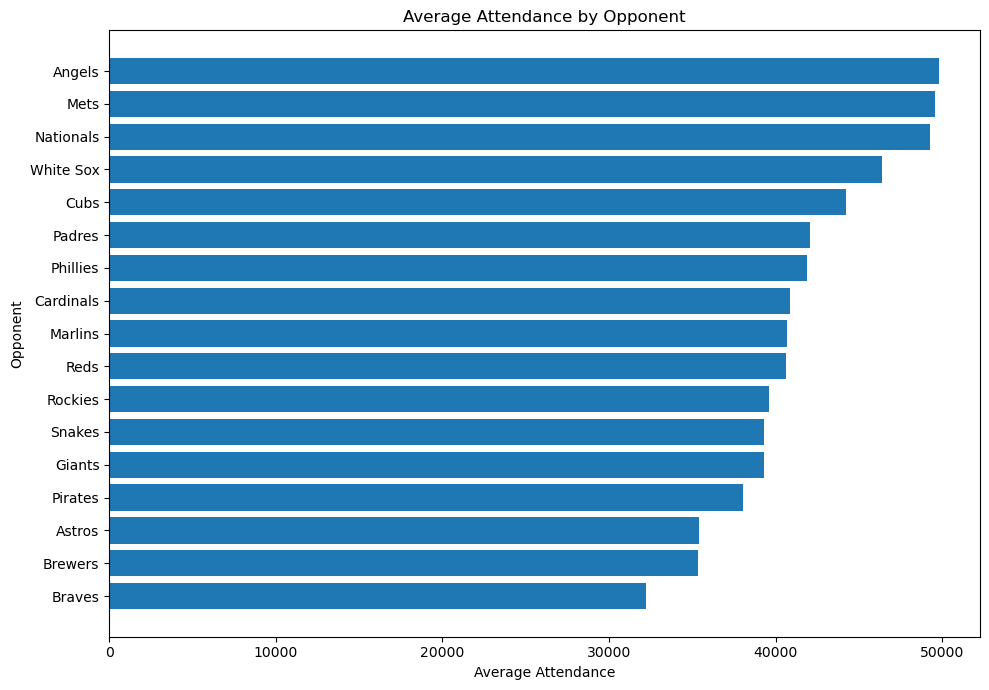

In [22]:
#Calculate average attendance by opponent
attendance_by_opponent = dodgers.groupby("opponent")["attend"].mean().reset_index()

#Sort opponents from lowest to highest average attendance
attendance_by_opponent = attendance_by_opponent.sort_values("attend", ascending=True)

#Create a horizontal bar chart for average attendance by opponent and output
plt.figure(figsize=(10, 7))

plt.barh(attendance_by_opponent["opponent"], attendance_by_opponent["attend"])

plt.title("Average Attendance by Opponent")
plt.xlabel("Average Attendance")
plt.ylabel("Opponent")
plt.tight_layout()

plt.show()

________

## Attendance by Promotion Type

Next, I compared average attendance by promotion type. Bobblehead games had the strongest attendance difference, averaging about 53,145 fans compared to about 39,138 fans for games without a bobblehead promotion.

Shirt games also had higher average attendance, but there were only a few shirt promotions in the dataset. Fireworks games were almost the same as non-fireworks games, and cap games did not show a higher average. Based on this comparison, bobbleheads appear to be the promotion type most clearly connected with higher attendance.

In [23]:
#Create promotion comparison table
promotion_columns = ["cap", "shirt", "fireworks", "bobblehead"]

promotion_summary = []

for promotion in promotion_columns:
    avg_yes = dodgers[dodgers[promotion] == "YES"]["attend"].mean()
    avg_no = dodgers[dodgers[promotion] == "NO"]["attend"].mean()
    
    promotion_summary.append({
        "Promotion": promotion,
        "Average Attendance With Promotion": avg_yes,
        "Average Attendance Without Promotion": avg_no
    })

promotion_summary = pd.DataFrame(promotion_summary)

#Format attendance values and output
promotion_summary["Average Attendance With Promotion"] = promotion_summary["Average Attendance With Promotion"].round(0)
promotion_summary["Average Attendance Without Promotion"] = promotion_summary["Average Attendance Without Promotion"].round(0)

promotion_summary

,Promotion,Average Attendance With Promotion,Average Attendance Without Promotion
0,cap,38190.0,41112.0
1,shirt,46644.0,40825.0
2,fireworks,41078.0,41032.0
3,bobblehead,53145.0,39138.0


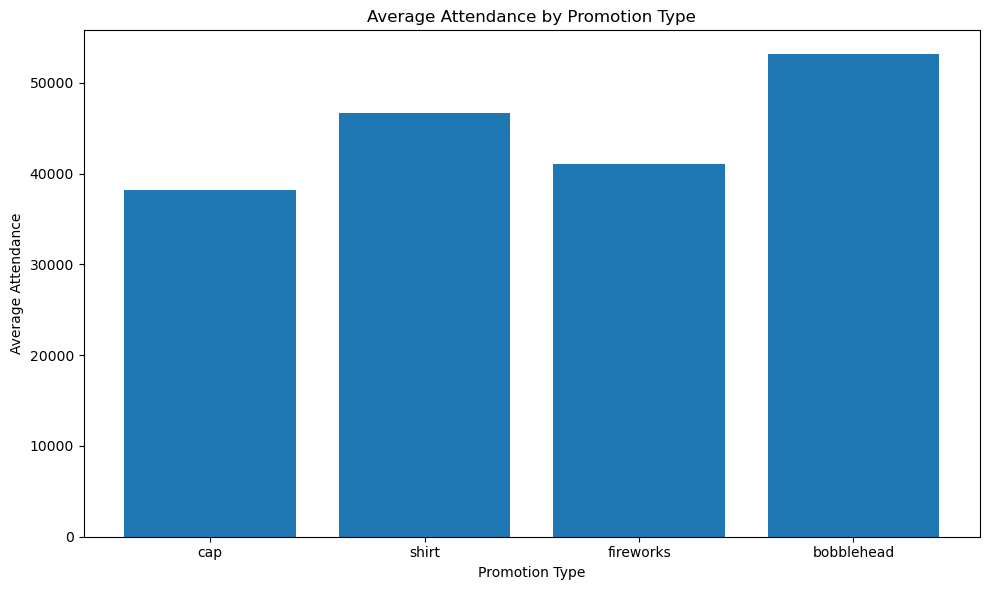

In [24]:
#Create bar chart comparing attendance with each promotion type and output
plt.figure(figsize=(10, 6))

plt.bar(
    promotion_summary["Promotion"],
    promotion_summary["Average Attendance With Promotion"]
)

plt.title("Average Attendance by Promotion Type")
plt.xlabel("Promotion Type")
plt.ylabel("Average Attendance")
plt.tight_layout()

plt.show()

________

## Bobblehead vs. Non-Bobblehead Attendance

After comparing the promotion types, bobbleheads stood out as the strongest promotion category. To show this more clearly, I compared the attendance distribution for games with a bobblehead promotion against games without one.

The boxplot shows that bobblehead games were generally much higher attended than non-bobblehead games. Bobblehead games were clustered near the top of the attendance range, while non-bobblehead games had a wider spread and included most of the lower-attendance games. This supports the idea that bobbleheads were the clearest promotion connected with stronger attendance.

Reminder: The 2012 bobblehead giveaway names and dates were based on the Dodgers 2012 bobblehead schedule published by MLB.

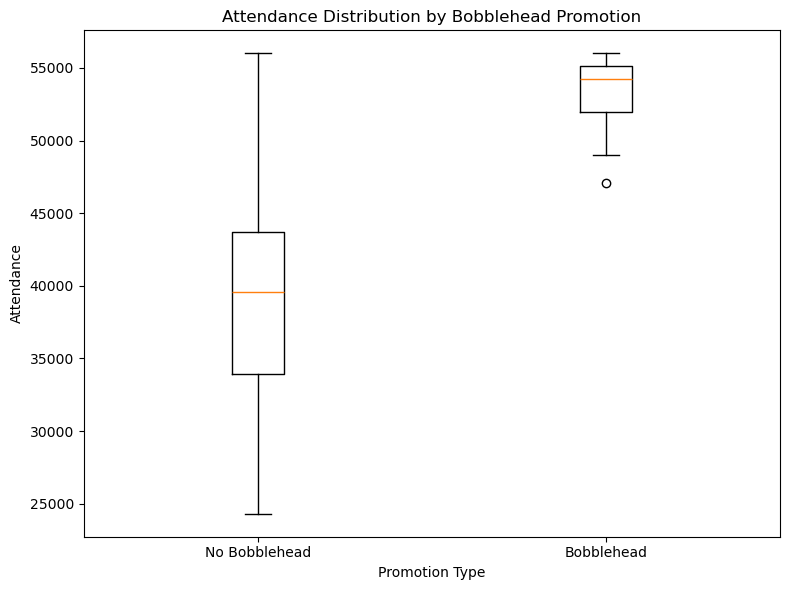

In [25]:
#Separate attendance for bobblehead and non-bobblehead games
bobblehead_yes = dodgers[dodgers["bobblehead"] == "YES"]["attend"]
bobblehead_no = dodgers[dodgers["bobblehead"] == "NO"]["attend"]

#Create a boxplot comparing attendance by bobblehead promotion and output
plt.figure(figsize=(8, 6))

plt.boxplot(
    [bobblehead_no, bobblehead_yes],
    tick_labels=["No Bobblehead", "Bobblehead"]
)

plt.title("Attendance Distribution by Bobblehead Promotion")
plt.xlabel("Promotion Type")
plt.ylabel("Attendance")
plt.tight_layout()

plt.show()

_________

## Weather and Game Time Conditions

Weather and game time did not show as strong of a pattern as bobblehead promotions. Clear-sky games averaged about 41,729 fans, while cloudy games averaged about 38,791 fans. Day games averaged about 41,793 fans, and night games averaged about 40,869 fans.

Temperature also did not show a strong relationship with attendance. The scatter plot shows that attendance varied across both cooler and warmer games, with no clear upward or downward pattern. This suggests that weather and game time may affect attendance somewhat, but they do not appear to explain attendance as clearly as promotions.

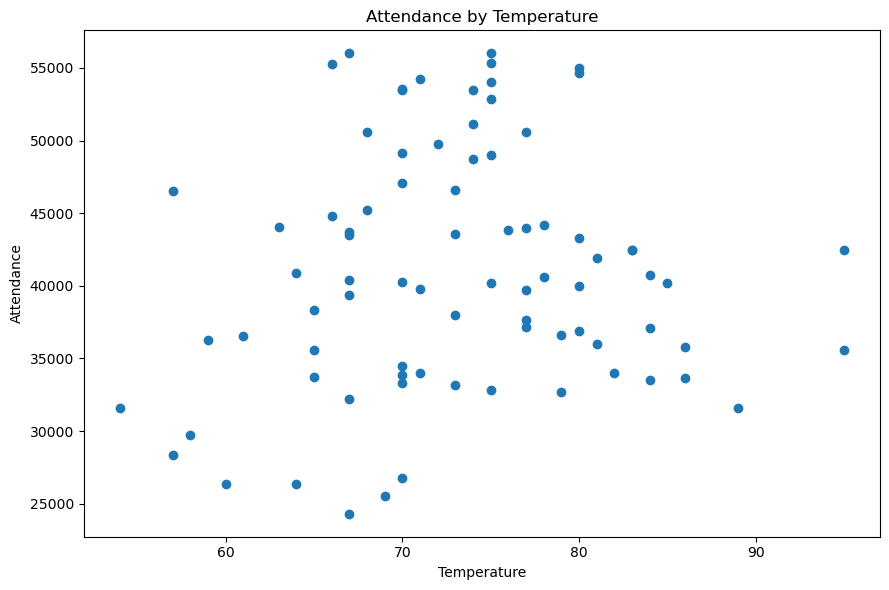

In [26]:
#Create a scatter plot to compare temperature and attendance and output
plt.figure(figsize=(9, 6))

plt.scatter(dodgers["temp"], dodgers["attend"])

plt.title("Attendance by Temperature")
plt.xlabel("Temperature")
plt.ylabel("Attendance")
plt.tight_layout()

plt.show()

________

## Attendance by Specific Bobblehead Giveaway

Since bobblehead promotions had the strongest attendance pattern, I added the specific bobblehead giveaway names to see which ones had the highest attendance. The original Dodgers dataset only shows whether a game had a bobblehead promotion, so I used MLB’s 2012 Dodgers bobblehead schedule to match the giveaway names to the correct game dates.

The results show that the highest-attended bobblehead games were tied to recognizable Dodgers figures and fan-interest themes, including Fernando Valenzuela, Hello Kitty, Mike Scioscia, Sandy Koufax, Vin Scully, and Don Drysdale/Maury Wills. This adds more detail to the promotion finding because it shows that the subject of the bobblehead may matter, not just the fact that a giveaway happened.

Source: MLB.com, 2012 Dodgers Bobbleheads schedule.

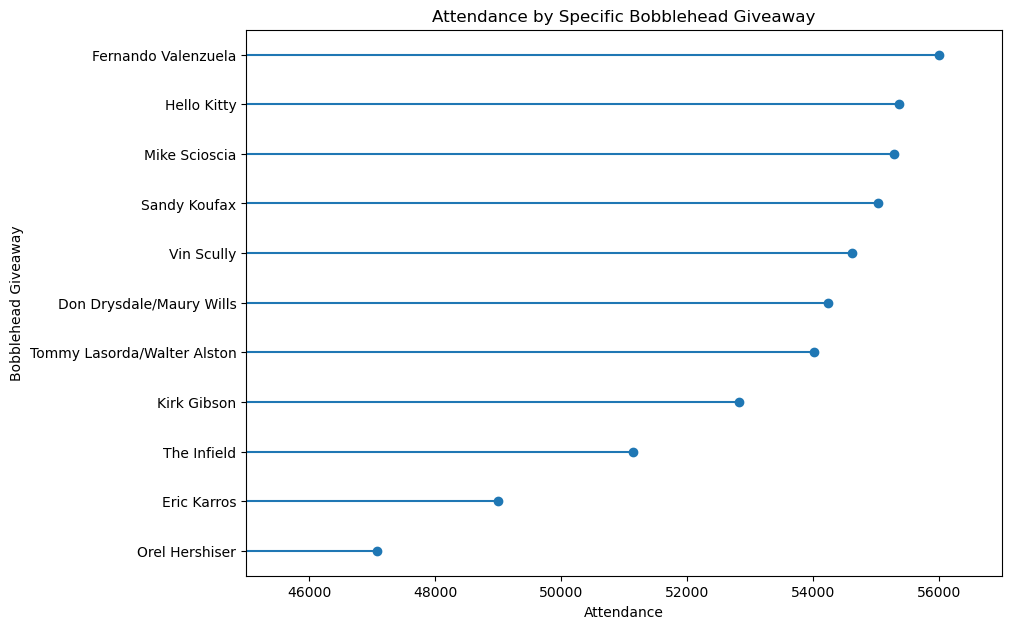

In [27]:
#Remove old bobblehead name columns if this cell has been run before
dodgers_clean = dodgers.drop(
    columns=["bobblehead_name", "bobblehead_name_x", "bobblehead_name_y"],
    errors="ignore"
)

#Create supplemental bobblehead giveaway table
bobblehead_schedule = pd.DataFrame({
    "game_date": pd.to_datetime([
        "2012-04-28", "2012-05-15", "2012-05-29", "2012-06-12",
        "2012-06-28", "2012-07-01", "2012-07-14", "2012-07-31",
        "2012-08-07", "2012-08-21", "2012-08-30"
    ]),
    "bobblehead_name": [
        "Don Drysdale/Maury Wills",
        "Orel Hershiser",
        "The Infield",
        "Mike Scioscia",
        "Eric Karros",
        "Hello Kitty",
        "Tommy Lasorda/Walter Alston",
        "Kirk Gibson",
        "Sandy Koufax",
        "Fernando Valenzuela",
        "Vin Scully"
    ]
})

#Merge bobblehead names with the Dodgers attendance data
dodgers_bobbleheads = dodgers_clean.merge(
    bobblehead_schedule,
    on="game_date",
    how="left"
)

#Keep bobblehead games and sort by attendance
bobblehead_games = dodgers_bobbleheads[
    dodgers_bobbleheads["bobblehead"] == "YES"
].sort_values("attend")

#Create a lollipop chart for bobblehead attendance
plt.figure(figsize=(12, 7))

plt.hlines(
    y=bobblehead_games["bobblehead_name"],
    xmin=45000,
    xmax=bobblehead_games["attend"]
)

plt.plot(
    bobblehead_games["attend"],
    bobblehead_games["bobblehead_name"],
    "o"
)

plt.title("Attendance by Specific Bobblehead Giveaway")
plt.xlabel("Attendance")
plt.ylabel("Bobblehead Giveaway")

#Set the x-axis closer to the attendance range
plt.xlim(45000, 57000)

#Add extra room for long labels and output
plt.subplots_adjust(left=0.32, right=0.95, top=0.90, bottom=0.12)

plt.show()

_________

## Summary and Recommendation 

Before giving the final recommendation, I want to press home that this analysis can't 100% guarantee that the recommendation will increase attendance, but I am giving this based on what I have found to be the strongest pattern in the data that will lead to increased attendance. 

The analysis done suggests that bobblehead promotions are the strongest attendance-related pattern in the dataset. Monday and Wednesday had weaker average attendance, while opponent, weather, and game time did not show as clear of a relationship.

Bobblehead games had much higher attendance than non-bobblehead games, and several of the strongest giveaways were tied to recognizable names and fan-interest themes, including Fernando Valenzuela, Sandy Koufax, Vin Scully, Mike Scioscia, and Hello Kitty.


Based on these findings, in order to bolster overall home game attendance, my recommendation is that Dodgers management use high-interest bobblehead promotions on games that are more likely to underperform, especially Monday and Wednesday games. NThis does not prove that bobbleheads caused higher attendance, but it is the strongest pattern in the analysis.